# LDPC ECC

## Dependencies

In [28]:
# !pip install stim~=1.15
# !pip install numpy~=1.0  # 1.0 instead of 2.0 for pymatching compatibility later
# !pip install scipy
# !pip install pymatching~=2.0
# !pip install sinter~=1.14
!pip install ldpc
!pip install stimbposd


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Import

In [29]:
import stim
import sinter
import numpy as np

print(stim.__version__)

1.15.0


## Random Sparse Parity Matrix Generation

In [ ]:
def gen_dynamic_ldpc_matrix(n, wc, wr):
    """
    Generates a regular (n, wc, wr) LDPC parity-check matrix.
    
    n: Number of data qubits
    
    wc: Weight per column (checks per bit)
    
    wr: Weight per row (bits per check)

    m = (n * wc) // wr : number of check equations
    """
    m = (n * wc) // wr  # Number of check equations
    
    # Create the base block
    block = np.zeros((m // wc, n), dtype=int)
    for i in range(m // wc):
        for j in range(wr):
            block[i, i * wr + j] = 1
            
    # Create H by stacking vertically with random permutations
    H_blocks = [block]
    for i in range(wc - 1):
        permuted_block = block[:, np.random.permutation(n)]
        H_blocks.append(permuted_block)
        
    H = np.vstack(H_blocks)
    return H

## Circuit Definition

In [31]:
from ldpc import mod2

def get_valid_logical(H):
    """
    Finds a valid logical operator for the given H matrix.
    """
    kernel = mod2.nullspace(H)
    if kernel.shape[0] == 0: return []
    
    # Find the row with the maximum number of 1s (max weight)
    weights = [np.sum(kernel[i].toarray()) for i in range(kernel.shape[0])]
    best_row_idx = np.argmax(weights)
    
    best_row = kernel[best_row_idx].toarray().flatten()
    return np.where(best_row == 1)[0].tolist()

def gen_ldpc_circuit(H, prob) -> stim.Circuit:
        
    circuit = stim.Circuit()
    # num_rows = ancilla qubits
    # num_cols = number of physical qubits
    num_rows, num_cols = H.shape
    data = list(range(num_cols))
    anc = list(range(num_cols,num_cols+num_rows))
    
    circuit.append("R", data + anc)
    circuit.append("X_ERROR", data, prob)
    circuit.append("H", anc)
    for i in range(num_rows):
        for j in range(num_cols):
            if(H[i][j] == 1):
                circuit.append("CZ", [anc[i], j])
        circuit.append("H", anc[i])
        circuit.append("M", anc[i])
        circuit.append("DETECTOR", [stim.target_rec(-1)])
    
    circuit.append("M", data) 

    # Find the valid logical indices (qubits)
    logical_indices = get_valid_logical(H)

    targets = [stim.target_rec(-num_cols + i) for i in logical_indices]

    # Include these measurement records as logical observable 0
    circuit.append("OBSERVABLE_INCLUDE", targets, 0)

 
    return circuit

## Circuit Simulation

In [35]:
import os
from stimbposd import sinter_decoders
H_d20 = gen_dynamic_ldpc_matrix(20, 3, 4)
H_d60 = gen_dynamic_ldpc_matrix(60, 3, 6)
H_d100 = gen_dynamic_ldpc_matrix(100, 3, 10)

tasks =  [
    sinter.Task(
        circuit=gen_ldpc_circuit(var_h,noise),
        json_metadata={'d' : d, 'p' : noise},
    )
    for d, var_h in [(20, H_d20), (60, H_d60), (100, H_d100)]
    for noise in [0.001, 0.005, 0.01, 0.02, 0.05, 0.08, 0.10, 0.12, 0.15]
]

var_samples = sinter.collect(
    num_workers=os.cpu_count(),
    max_shots=1_000_000,
    max_errors=500,
    tasks=tasks,
    decoders=['bposd'],
    custom_decoders=sinter_decoders()
)

## Results

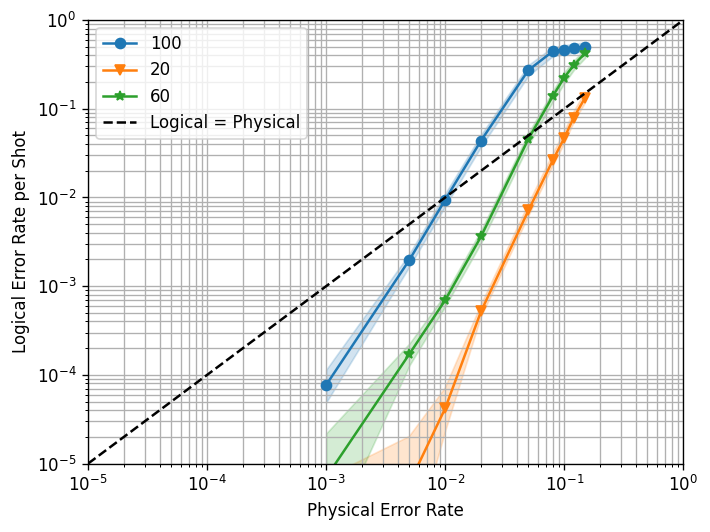

In [36]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=var_samples,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
)

x_vals = np.logspace(-5, 0, 100) # Match the range of your x-axis
ax.plot(x_vals, x_vals, color='black', linestyle='--', label='Logical = Physical')

ax.set_ylim(1e-5, 1e-0)
ax.set_xlim(1e-5, 1e-0)
ax.loglog()
# ax.set_title("Repetition Code Error Rates (Phenomenological Noise)")
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger